In [2]:
import pandas as pd

# Load datasets
bom_df = pd.read_csv("../data/bom.movie_gross.csv")
tn_movie_budgets_df = pd.read_csv("../data/tn.movie_budgets.csv")

# Step 1: Clean financial columns
# Remove commas from foreign_gross in Box Office Mojo and convert to float
bom_df['foreign_gross'] = bom_df['foreign_gross'].str.replace(',', '').astype(float, errors='ignore')

# Remove $ and commas from The Numbers financial columns and convert to float
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    tn_movie_budgets_df[col] = tn_movie_budgets_df[col].str.replace('[\$,]', '', regex=True).astype(float)

# Step 2: Extract year from release_date in The Numbers for matching
tn_movie_budgets_df['year'] = pd.to_datetime(tn_movie_budgets_df['release_date']).dt.year

# Step 3: Normalize titles for merging
bom_df['title_clean'] = bom_df['title'].str.lower().str.replace(r'[^\w\s]', '', regex=True)
tn_movie_budgets_df['movie_clean'] = tn_movie_budgets_df['movie'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Step 4: Merge datasets on cleaned titles and year
merged_df = pd.merge(
    bom_df,
    tn_movie_budgets_df,
    left_on=['title_clean', 'year'],
    right_on=['movie_clean', 'year'],
    how='left'  # Keep all Box Office Mojo records
)

# Step 5: Impute missing foreign_gross
# Calculate foreign_gross as worldwide_gross - domestic_gross where foreign_gross is NaN
merged_df['foreign_gross'] = merged_df.apply(
    lambda row: row['worldwide_gross'] - row['domestic_gross_y'] 
    if pd.isna(row['foreign_gross']) and not pd.isna(row['worldwide_gross']) and not pd.isna(row['domestic_gross_y'])
    else row['foreign_gross'],
    axis=1
)

# Step 6: Validate imputed values
# Ensure foreign_gross is non-negative
merged_df['foreign_gross'] = merged_df['foreign_gross'].clip(lower=0)

# Step 7: Clean up merged dataset
# Drop temporary columns and rename domestic_gross columns for clarity
merged_df = merged_df.drop(['title_clean', 'movie_clean'], axis=1)
merged_df = merged_df.rename(columns={
    'domestic_gross_x': 'domestic_gross_bom',
    'domestic_gross_y': 'domestic_gross_tn'
})

# Step 8: Check results
print("Merged Dataset Shape:", merged_df.shape)
print("\nMissing foreign_gross after imputation:", merged_df['foreign_gross'].isna().sum())
print("\nSample of Merged Dataset:")
print(merged_df[['title', 'year', 'foreign_gross', 'worldwide_gross', 'domestic_gross_tn']].head())

# Optional: Save the merged and imputed dataset
merged_df.to_csv("../data/cleaned_data/merged_movie_gross.csv", index=False)

Merged Dataset Shape: (3387, 11)

Missing foreign_gross after imputation: 1190

Sample of Merged Dataset:
                                         title  year  foreign_gross  \
0                                  Toy Story 3  2010    652000000.0   
1                   Alice in Wonderland (2010)  2010    691300000.0   
2  Harry Potter and the Deathly Hallows Part 1  2010    664300000.0   
3                                    Inception  2010    535700000.0   
4                          Shrek Forever After  2010    513900000.0   

   worldwide_gross  domestic_gross_tn  
0     1.068880e+09        415004880.0  
1              NaN                NaN  
2              NaN                NaN  
3     8.355246e+08        292576195.0  
4     7.562447e+08        238736787.0  


In [16]:
import pandas as pd

# Load datasets
bom_df = pd.read_csv("../data/bom.movie_gross.csv")
tn_movie_budgets_df = pd.read_csv("../data/tn.movie_budgets.csv")

# Step 1: Clean financial columns
# Remove commas from foreign_gross in Box Office Mojo and convert to float
bom_df['foreign_gross'] = bom_df['foreign_gross'].str.replace(',', '').astype(float, errors='ignore')

# Remove $ and commas from The Numbers financial columns and convert to float
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    tn_movie_budgets_df[col] = tn_movie_budgets_df[col].str.replace('[\$,]', '', regex=True).astype(float)

# Step 2: Extract year from release_date in The Numbers for matching
tn_movie_budgets_df['year'] = pd.to_datetime(tn_movie_budgets_df['release_date']).dt.year

# Step 3: Normalize titles for merging
bom_df['title_clean'] = bom_df['title'].str.lower().str.replace(r'[^\w\s]', '', regex=True)
tn_movie_budgets_df['movie_clean'] = tn_movie_budgets_df['movie'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Step 4: Merge datasets on cleaned titles and year
merged_df = pd.merge(
    bom_df,
    tn_movie_budgets_df,
    left_on=['title_clean', 'year'],
    right_on=['movie_clean', 'year'],
    how='left'  # Keep all Box Office Mojo records
)

# Step 5: Impute missing foreign_gross
merged_df['foreign_gross'] = merged_df.apply(
    lambda row: row['worldwide_gross'] - row['domestic_gross_y'] 
    if pd.isna(row['foreign_gross'])
    else row['foreign_gross'],
    axis=1
)

# Step 6: Validate imputed values (ensure non-negative)
merged_df['foreign_gross'] = merged_df['foreign_gross'].clip(lower=0)

# Step 7: Filter rows with remaining missing foreign_gross
merged_df_filtered = merged_df.dropna(subset=['foreign_gross'])

# Step 8: Clean up merged dataset
merged_df_filtered = merged_df_filtered.drop(['title_clean', 'movie_clean'], axis=1)
merged_df_filtered = merged_df_filtered.rename(columns={
    'domestic_gross_x': 'domestic_gross_bom',
    'domestic_gross_y': 'domestic_gross_tn'
})

# Step 9: Check results
print("Original Dataset Shape:", bom_df.shape)
print("Merged Dataset Shape (before filtering):", merged_df.shape)
print("Filtered Dataset Shape (after filtering):", merged_df_filtered.shape)
print("\nMissing foreign_gross before imputation:", bom_df['foreign_gross'].isna().sum())
print("Missing foreign_gross after imputation:", merged_df['foreign_gross'].isna().sum())
print("Missing foreign_gross after filtering:", merged_df_filtered['foreign_gross'].isna().sum())
print("\nSample of Filtered Dataset:")
print(merged_df_filtered[['title', 'year', 'foreign_gross', 'worldwide_gross', 'domestic_gross_tn']].head())

# Optional: Save the filtered dataset
merged_df_filtered.to_csv("../data/merged_movie_gross_filtered.csv", index=False)

Original Dataset Shape: (3387, 6)
Merged Dataset Shape (before filtering): (3387, 13)
Filtered Dataset Shape (after filtering): (2197, 11)

Missing foreign_gross before imputation: 1350
Missing foreign_gross after imputation: 1190
Missing foreign_gross after filtering: 0

Sample of Filtered Dataset:
                                         title  year  foreign_gross  \
0                                  Toy Story 3  2010    652000000.0   
1                   Alice in Wonderland (2010)  2010    691300000.0   
2  Harry Potter and the Deathly Hallows Part 1  2010    664300000.0   
3                                    Inception  2010    535700000.0   
4                          Shrek Forever After  2010    513900000.0   

   worldwide_gross  domestic_gross_tn  
0     1.068880e+09        415004880.0  
1              NaN                NaN  
2              NaN                NaN  
3     8.355246e+08        292576195.0  
4     7.562447e+08        238736787.0  


In [1]:
import pandas as pd
from fuzzywuzzy import process, fuzz

# Load datasets
bom_df = pd.read_csv("../data/bom.movie_gross.csv")
tn_movie_budgets_df = pd.read_csv("../data/tn.movie_budgets.csv")

# --- Cleaning Box Office Mojo Dataset ---
print("\nCleaning Box Office Mojo Dataset...")

# Convert foreign_gross to float
bom_df['foreign_gross'] = bom_df['foreign_gross'].str.replace(',', '', regex=True).astype(float, errors='ignore')

# Handle missing values
bom_df['studio'] = bom_df['studio'].fillna('Unknown')
bom_df['domestic_gross'] = bom_df['domestic_gross'].fillna(bom_df['domestic_gross'].median())
print("Missing values in Box Office Mojo:")
print(bom_df.isna().sum())

# Normalize titles
bom_df['title_clean'] = bom_df['title'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Remove duplicates
bom_df = bom_df.drop_duplicates(subset=['title', 'year'], keep='first')

# --- Cleaning The Numbers Dataset ---
print("\nCleaning The Numbers Dataset...")

# Convert financial columns to float
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    tn_movie_budgets_df[col] = tn_movie_budgets_df[col].str.replace('[\$,]', '', regex=True).astype(float)

# Convert release_date to datetime and extract year
tn_movie_budgets_df['release_date'] = pd.to_datetime(tn_movie_budgets_df['release_date'], errors='coerce')
tn_movie_budgets_df['year'] = tn_movie_budgets_df['release_date'].dt.year

# Normalize titles
tn_movie_budgets_df['movie_clean'] = tn_movie_budgets_df['movie'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# Remove duplicates
tn_movie_budgets_df = tn_movie_budgets_df.drop_duplicates(subset=['movie', 'year'], keep='first')

# --- Fuzzy Matching ---
print("\nPerforming Fuzzy Matching...")

# Function for fuzzy matching
def match_titles(title, choices, threshold=90):
    result = process.extractOne(title, choices, scorer=fuzz.token_sort_ratio)
    if result and result[1] >= threshold:
        return result[0], result[1]  # Return matched title and score
    return None, None

# Create a list of cleaned titles from Box Office Mojo
bom_titles = bom_df['title_clean'].tolist()

# Apply fuzzy matching to The Numbers titles
tn_movie_budgets_df['matched_title'], tn_movie_budgets_df['match_score'] = zip(
    *tn_movie_budgets_df['movie_clean'].apply(lambda x: match_titles(x, bom_titles))
)

# --- Merge Datasets ---
print("\nMerging Datasets...")

# Merge on fuzzy-matched titles and year
merged_df = pd.merge(
    bom_df,
    tn_movie_budgets_df,
    left_on=['title_clean', 'year'],
    right_on=['matched_title', 'year'],
    how='left'  # Keep all Box Office Mojo records
)

# --- Impute foreign_gross ---
print("\nImputing Missing foreign_gross...")
merged_df['foreign_gross'] = merged_df.apply(
    lambda row: row['worldwide_gross'] - row['domestic_gross_y']
    if pd.isna(row['foreign_gross']) and not pd.isna(row['worldwide_gross']) and not pd.isna(row['domestic_gross_y'])
    else row['foreign_gross'],
    axis=1
)

# Ensure non-negative foreign_gross
merged_df['foreign_gross'] = merged_df['foreign_gross'].clip(lower=0)

# --- Filter Rows with Missing foreign_gross ---
print("\nFiltering Rows with Missing foreign_gross...")
merged_df_filtered = merged_df.dropna(subset=['foreign_gross'])

# --- Clean Up ---
merged_df_filtered = merged_df_filtered.drop(['title_clean', 'movie_clean', 'matched_title', 'match_score'], axis=1, errors='ignore')
merged_df_filtered = merged_df_filtered.rename(columns={
    'domestic_gross_x': 'domestic_gross_bom',
    'domestic_gross_y': 'domestic_gross_tn'
})

# --- Check Results ---
print("\nResults:")
print("Original Box Office Mojo Shape:", bom_df.shape)
print("Original The Numbers Shape:", tn_movie_budgets_df.shape)
print("Merged Dataset Shape (before filtering):", merged_df.shape)
print("Filtered Dataset Shape (after filtering):", merged_df_filtered.shape)
print("\nMissing foreign_gross before imputation:", bom_df['foreign_gross'].isna().sum())
print("Missing foreign_gross after imputation:", merged_df['foreign_gross'].isna().sum())
print("Missing foreign_gross after filtering:", merged_df_filtered['foreign_gross'].isna().sum())
print("\nSample of Filtered Dataset:")
print(merged_df_filtered[['title', 'year', 'foreign_gross', 'worldwide_gross', 'domestic_gross_tn']].head())

# Save the filtered dataset
merged_df_filtered.to_csv("data/merged_movie_gross_filtered_fuzzy.csv", index=False)


Cleaning Box Office Mojo Dataset...
Missing values in Box Office Mojo:
title                0
studio               0
domestic_gross       0
foreign_gross     1350
year                 0
dtype: int64

Cleaning The Numbers Dataset...

Performing Fuzzy Matching...

Merging Datasets...

Imputing Missing foreign_gross...

Filtering Rows with Missing foreign_gross...

Results:
Original Box Office Mojo Shape: (3387, 6)
Original The Numbers Shape: (5781, 10)
Merged Dataset Shape (before filtering): (3387, 15)
Filtered Dataset Shape (after filtering): (2202, 11)

Missing foreign_gross before imputation: 1350
Missing foreign_gross after imputation: 1185
Missing foreign_gross after filtering: 0

Sample of Filtered Dataset:
                                         title  year  foreign_gross  \
0                                  Toy Story 3  2010    652000000.0   
1                   Alice in Wonderland (2010)  2010    691300000.0   
2  Harry Potter and the Deathly Hallows Part 1  2010    66430000

FileNotFoundError: [Errno 2] No such file or directory: 'data/merged_movie_gross_filtered_fuzzy.csv'

In [11]:
# loading the sqlite database
import sqlite3
con= sqlite3.connect("../data/im.db") #creating a connection

# previewing the schema
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type= "table";
""", con)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [12]:
# joining the two tables using movie_id
query= """
SELECT *
FROM movie_basics
LEFT JOIN movie_ratings
USING(movie_id);
"""
movie_basics_rating_df= pd.read_sql(query, con)
movie_basics_rating_df.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama,NaN,NaN
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary,NaN,NaN
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy,NaN,NaN
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None,NaN,NaN
146143,tt9916754,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,NaN,Documentary,NaN,NaN


In [15]:
import pandas as pd
import os
import csv

# Function to check if file is gzip-compressed
def is_gzipped(file_path):
    try:
        with open(file_path, 'rb') as f:
            return f.read(2) == b'\x1f\x8b'  # Gzip magic number
    except:
        return False

# File paths
movie_info_path = '../data/rt.movie_info.tsv'
reviews_path = '../data/rt.reviews.tsv'

# Load movie_info
if os.path.exists(movie_info_path):
    compression = 'gzip' if is_gzipped(movie_info_path) else None
    try:
        movie_info = pd.read_csv(
            movie_info_path,
            sep='\t',
            compression=compression,
            encoding='utf-8',
            na_values=['', 'N/A'],
            quoting=csv.QUOTE_ALL,  # Handle delimiters
            error_bad_lines=False  # Skip malformed rows (pandas <1.3.0)
        )
        print("Movie Info Loaded Successfully:", movie_info.shape)
        print("Movie Info Columns:", movie_info.columns)
    except Exception as e:
        print("Error loading movie_info:", e)
else:
    print(f"File not found: {movie_info_path}")

# Load reviews with alternative encoding
if os.path.exists(reviews_path):
    compression = 'gzip' if is_gzipped(reviews_path) else None
    try:
        reviews = pd.read_csv(
            reviews_path,
            sep='\t',
            compression=compression,
            encoding='latin1',  # Try latin1 to handle non-UTF-8 characters
            na_values=['', 'N/A'],
            quoting=csv.QUOTE_ALL,
            error_bad_lines=False
        )
        print("Reviews Loaded Successfully:", reviews.shape)
        print("Reviews Columns:", reviews.columns)
    except Exception as e:
        print("Error loading reviews:", e)
        # Fallback: Try ignoring encoding errors
        try:
            reviews = pd.read_csv(
                reviews_path,
                sep='\t',
                compression=compression,
                encoding='utf-8',
                encoding_errors='ignore',  # Ignore invalid bytes
                na_values=['', 'N/A'],
                quoting=csv.QUOTE_ALL,
                error_bad_lines=False
            )
            print("Reviews Loaded with encoding_errors='ignore':", reviews.shape)
        except Exception as e2:
            print("Fallback error:", e2)
else:
    print(f"File not found: {reviews_path}")

# Inspect datasets
print("Movie Info Shape:", movie_info.shape)
print("Reviews Shape:", reviews.shape)
print("\nMovie Info Missing Values:\n", movie_info.isnull().sum())
print("\nReviews Missing Values:\n", reviews.isnull().sum())

# Clean reviews: Drop rows with missing 'fresh' values
reviews = reviews.dropna(subset=['fresh'])

# Clean movie_info: Drop rows with missing 'genre'
movie_info = movie_info.dropna(subset=['genre'])

# Verify cleaned data
print("\nCleaned Movie Info Shape:", movie_info.shape)
print("Cleaned Reviews Shape:", reviews.shape)

Movie Info Loaded Successfully: (1560, 12)
Movie Info Columns: Index(['id', 'synopsis', 'rating', 'genre', 'director', 'writer',
       'theater_date', 'dvd_date', 'currency', 'box_office', 'runtime',
       'studio'],
      dtype='object')
Reviews Loaded Successfully: (54432, 8)
Reviews Columns: Index(['id', 'review', 'rating', 'fresh', 'critic', 'top_critic', 'publisher',
       'date'],
      dtype='object')
Movie Info Shape: (1560, 12)
Reviews Shape: (54432, 8)

Movie Info Missing Values:
 id                 0
synopsis          62
rating             3
genre              8
director         199
writer           449
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime           30
studio          1066
dtype: int64

Reviews Missing Values:
 id                0
review         5563
rating        13517
fresh             0
critic         2722
top_critic        0
publisher       309
date              0
dtype: int64

Cleaned Movie Info Shape: (1552, 12)

In [16]:
# Inspect datasets
if 'movie_info' in locals():
    print("Movie Info Shape:", movie_info.shape)
    print("Movie Info Columns:", movie_info.columns)
    print("\nMovie Info Missing Values:\n", movie_info.isnull().sum())
else:
    print("movie_info not loaded")

if 'reviews' in locals():
    print("Reviews Shape:", reviews.shape)
    print("Reviews Columns:", reviews.columns)
    print("\nReviews Missing Values:\n", reviews.isnull().sum())
else:
    print("reviews not loaded")

Movie Info Shape: (1552, 12)
Movie Info Columns: Index(['id', 'synopsis', 'rating', 'genre', 'director', 'writer',
       'theater_date', 'dvd_date', 'currency', 'box_office', 'runtime',
       'studio'],
      dtype='object')

Movie Info Missing Values:
 id                 0
synopsis          57
rating             0
genre              0
director         192
writer           442
theater_date     351
dvd_date         351
currency        1212
box_office      1212
runtime           26
studio          1058
dtype: int64
Reviews Shape: (54432, 8)
Reviews Columns: Index(['id', 'review', 'rating', 'fresh', 'critic', 'top_critic', 'publisher',
       'date'],
      dtype='object')

Reviews Missing Values:
 id                0
review         5563
rating        13517
fresh             0
critic         2722
top_critic        0
publisher       309
date              0
dtype: int64


In [27]:
# Calculate freshness score per movie
freshness = reviews.groupby('id').apply(
    lambda x: pd.Series({
        'freshness_score': (x['fresh'] == 'fresh').mean(),
        'total_reviews': len(x)
    })
).reset_index()

# Filter movies with sufficient reviews (e.g., >= 10) to reduce noise
freshness = freshness[freshness['total_reviews'] >= 10]

# Merge with movie info (left join to retain movies with reviews)
merged_df = pd.merge(movie_info, freshness, on='id', how='inner')

# Drop rows with missing freshness_score
merged_df = merged_df.dropna(subset=['freshness_score'])

# Split multi-valued genres
merged_df['genre_list'] = merged_df['genre'].str.split('|')

# Explode genres for individual genre analysis
genre_exploded = merged_df.explode('genre_list')

# Verify data
print("Merged Data Shape:", merged_df.shape)
print("Exploded Genres Shape:", genre_exploded.shape)
print("Unique Genres:", genre_exploded['genre_list'].unique())

Merged Data Shape: (798, 15)
Exploded Genres Shape: (1820, 15)
Unique Genres: ['Drama' 'Science Fiction and Fantasy' 'Musical and Performing Arts'
 'Mystery and Suspense' 'Kids and Family' 'Comedy' 'Action and Adventure'
 'Documentary' 'Special Interest' 'Art House and International' 'Classics'
 'Romance' 'Horror' 'Sports and Fitness' 'Animation' 'Western'
 'Faith and Spirituality' 'Television' 'Gay and Lesbian' 'Cult Movies'
 'Anime and Manga']


In [23]:
freshness

,id,freshness_score,total_reviews
0,3,0.631902,163.0
1,5,0.782609,23.0
2,6,0.561404,57.0
3,8,0.746667,75.0
4,10,0.462963,108.0
...,...,...,...
1129,1995,0.162393,117.0
1130,1996,0.671329,143.0
1131,1997,0.357143,28.0
1133,1999,0.586957,46.0


In [28]:
# Aggregate freshness score by genre
genre_freshness = genre_exploded.groupby('genre_list')['freshness_score'].agg(['mean', 'std', 'count']).reset_index()
genre_freshness.columns = ['genre', 'avg_freshness_score', 'std_freshness_score', 'movie_count']

# Sort by average freshness score and select top 5
top_5_genres = genre_freshness.sort_values('avg_freshness_score', ascending=False).head(5)

# Format freshness score for readability
top_5_genres['avg_freshness_score_formatted'] = top_5_genres['avg_freshness_score'].apply(lambda x: f"{x:.2%}")

# Display results
print("Top 5 Genres by Average Freshness Score:\n", top_5_genres[['genre', 'avg_freshness_score_formatted', 'std_freshness_score', 'movie_count']])

Top 5 Genres by Average Freshness Score:
                           genre avg_freshness_score_formatted  \
6                   Cult Movies                        93.02%   
4                      Classics                        83.18%   
10              Gay and Lesbian                        80.36%   
3   Art House and International                        76.78%   
7                   Documentary                        75.83%   

    std_freshness_score  movie_count  
6                   NaN            1  
4              0.189389           67  
10             0.227284            2  
3              0.191384          100  
7              0.189154           25  


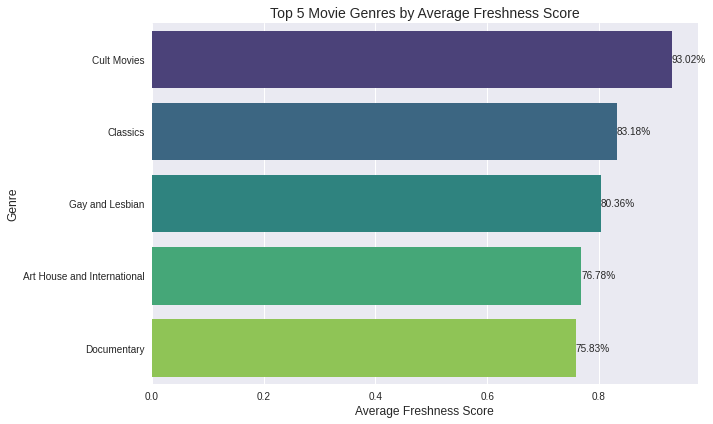

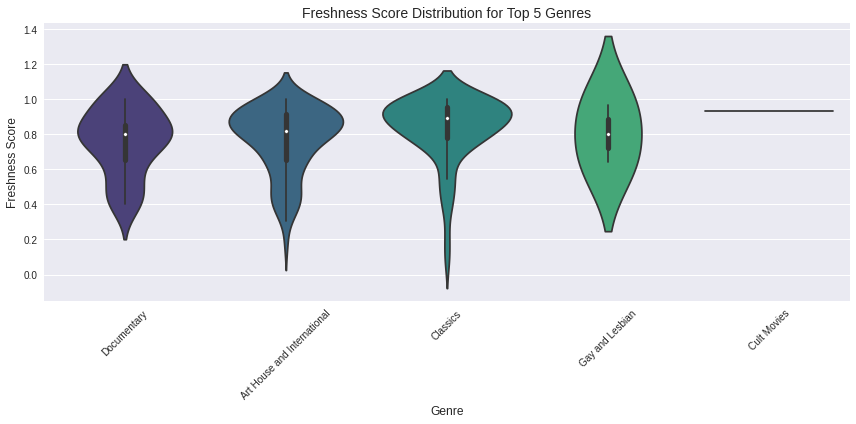

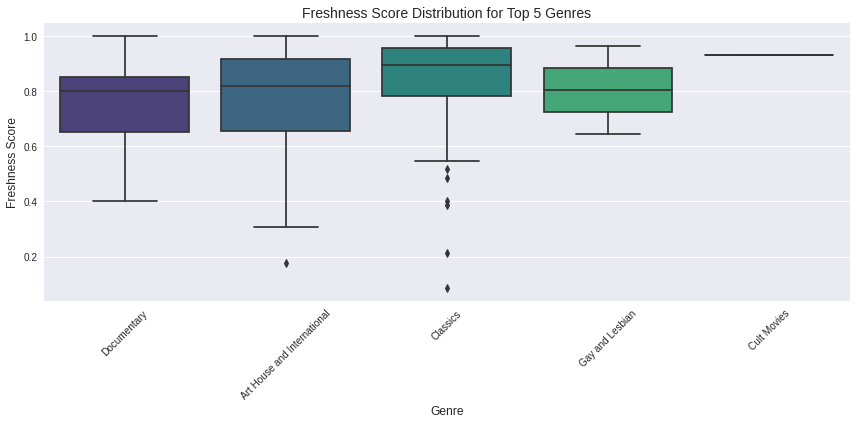

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style for professional presentation
plt.style.use('seaborn')
%matplotlib inline
# Visualization 1: Bar Plot of Average Freshness Score

plt.figure(figsize=(10, 6))
sns.barplot(x='avg_freshness_score', y='genre', data=top_5_genres, palette='viridis')
plt.title('Top 5 Movie Genres by Average Freshness Score', fontsize=14)
plt.xlabel('Average Freshness Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
for i, v in enumerate(top_5_genres['avg_freshness_score']):
    plt.text(v, i, f"{v:.2%}", va='center', fontsize=10)
plt.tight_layout()
plt.savefig('top_5_genres_freshness_bar.png')
plt.show()

# Visualization 2: Violin Plot of Freshness Score Distribution
plt.figure(figsize=(12, 6))
sns.violinplot(x='genre_list', y='freshness_score', data=genre_exploded[genre_exploded['genre_list'].isin(top_5_genres['genre'])], palette='viridis')
plt.title('Freshness Score Distribution for Top 5 Genres', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Freshness Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_5_genres_freshness_violin.png')
plt.show()

# Visualization 3: Box Plot of Freshness Score Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x='genre_list', y='freshness_score', data=genre_exploded[genre_exploded['genre_list'].isin(top_5_genres['genre'])], palette='viridis')
plt.title('Freshness Score Distribution for Top 5 Genres', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Freshness Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_5_genres_freshness_box.png')
plt.show()